1- KÜTÜPHANELERİN İÇERİ AKTARILMASI

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

2- DOSYA YOLLARININ TANIMLANMASI

In [2]:
PROJECT_ROOT = Path("..").resolve()

DATA_DIR = PROJECT_ROOT / "data"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
RESULTS_DIR = REPORTS_DIR / "results"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

X_TRAIN_PATH = DATA_DIR / "X_train.csv"
Y_TRAIN_PATH = DATA_DIR / "y_train.csv"
X_TEST_PATH = DATA_DIR / "X_test.csv"
Y_TEST_PATH = DATA_DIR / "y_test.csv"

X_TRAIN_SCALED_PATH = DATA_DIR / "X_train_scaled.csv"
X_TEST_SCALED_PATH = DATA_DIR / "X_test_scaled.csv"

KISI2_RESULTS_PATH = RESULTS_DIR / "kisi2_model_sonuclari.csv"

print("Proje klasörü:", PROJECT_ROOT)
print("Sonuc dosyası:", KISI2_RESULTS_PATH)

Proje klasörü: C:\Users\AHMET ÇOLAK\Desktop\Veri_Bilimi_Proje
Sonuc dosyası: C:\Users\AHMET ÇOLAK\Desktop\Veri_Bilimi_Proje\reports\results\kisi2_model_sonuclari.csv


3- ORTAK VERİLERİN OKUNMASİ

In [3]:
X_train = pd.read_csv(X_TRAIN_PATH)
X_test = pd.read_csv(X_TEST_PATH)

y_train = pd.read_csv(Y_TRAIN_PATH).squeeze()
y_test = pd.read_csv(Y_TEST_PATH).squeeze()

X_train_scaled = pd.read_csv(X_TRAIN_SCALED_PATH)
X_test_scaled = pd.read_csv(X_TEST_SCALED_PATH)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

X_train: (10834, 16)
X_test: (2709, 16)
y_train: (10834,)
y_test: (2709,)
X_train_scaled: (10834, 16)
X_test_scaled: (2709, 16)


4- SINIFLARIN KONTROLÜ

In [4]:
class_labels = sorted(y_test.unique())

print("Sınıflar:")
print(class_labels)

Sınıflar:
['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


5- ORTAK DEGERLENDİRME FONKSİYONU

In [5]:
def evaluate_model(model_name, model, X_train_data, X_test_data, y_train, y_test):
    model.fit(X_train_data, y_train)
    y_pred = model.predict(X_test_data)

    accuracy = accuracy_score(y_test, y_pred)
    weighted_precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    weighted_recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    weighted_f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    print(f"\n{model_name} Sonuçları:")
    print(f"Accuracy: {accuracy}")
    print(f"Weighted Precision: {weighted_precision}")
    print(f"Weighted Recall: {weighted_recall}")
    print(f"Weighted F1-score: {weighted_f1}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred, labels = class_labels)

    results = {
        "Model": model_name,
        "Accuracy": accuracy,
        "Weighted Precision": weighted_precision,
        "Weighted Recall": weighted_recall,
        "Weighted F1-score": weighted_f1
    }
    
    return results, cm, y_pred

6- CONFUSİON MATRİX KAYDETME FONKSİYONU

In [6]:
def save_confusion_matrix(cm, model_name, file_path):
    plt.figure(figsize=(8, 6), dpi=150)
    
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels
    )
    
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Tahmin Edilen Sınıf")
    plt.ylabel("Gerçek Sınıf")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    
    print(f"{model_name} confusion_matrix kaydedildi: {file_path}")

7- SVM MODELİ


SVM Sonuçları:
Accuracy: 0.9210040605389442
Weighted Precision: 0.9214106079511519
Weighted Recall: 0.9210040605389442
Weighted F1-score: 0.9210779160652252

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.94      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.95      0.93       326
    DERMASON       0.92      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.95      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



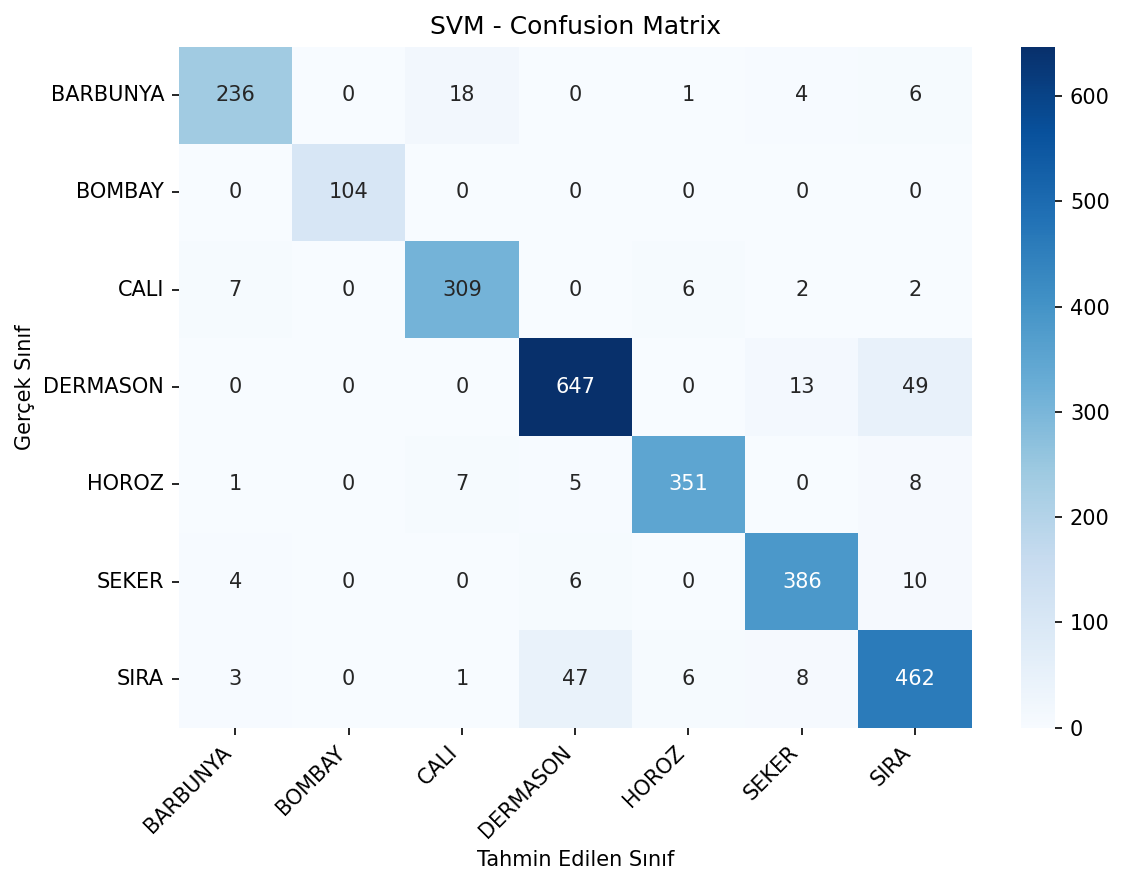

SVM confusion_matrix kaydedildi: C:\Users\AHMET ÇOLAK\Desktop\Veri_Bilimi_Proje\reports\figures\kisi2_svm_confusion_matrix.png


In [7]:
results = []
confusion_matrices = {}

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

svm_results, svm_cm, svm_pred = evaluate_model(
    "SVM",
    svm_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

results.append(svm_results)
confusion_matrices["SVM"] = svm_cm

save_confusion_matrix(
    svm_cm,
    "SVM",
    FIGURES_DIR / "kisi2_svm_confusion_matrix.png"
)

8- RANDOM FOREST MODELİ


Random Forest Sonuçları:
Accuracy: 0.9169435215946844
Weighted Precision: 0.9170186688639367
Weighted Recall: 0.9169435215946844
Weighted F1-score: 0.9168872723620085

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.93      0.92       326
    DERMASON       0.91      0.92      0.91       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.96      0.95       406
        SIRA       0.86      0.85      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



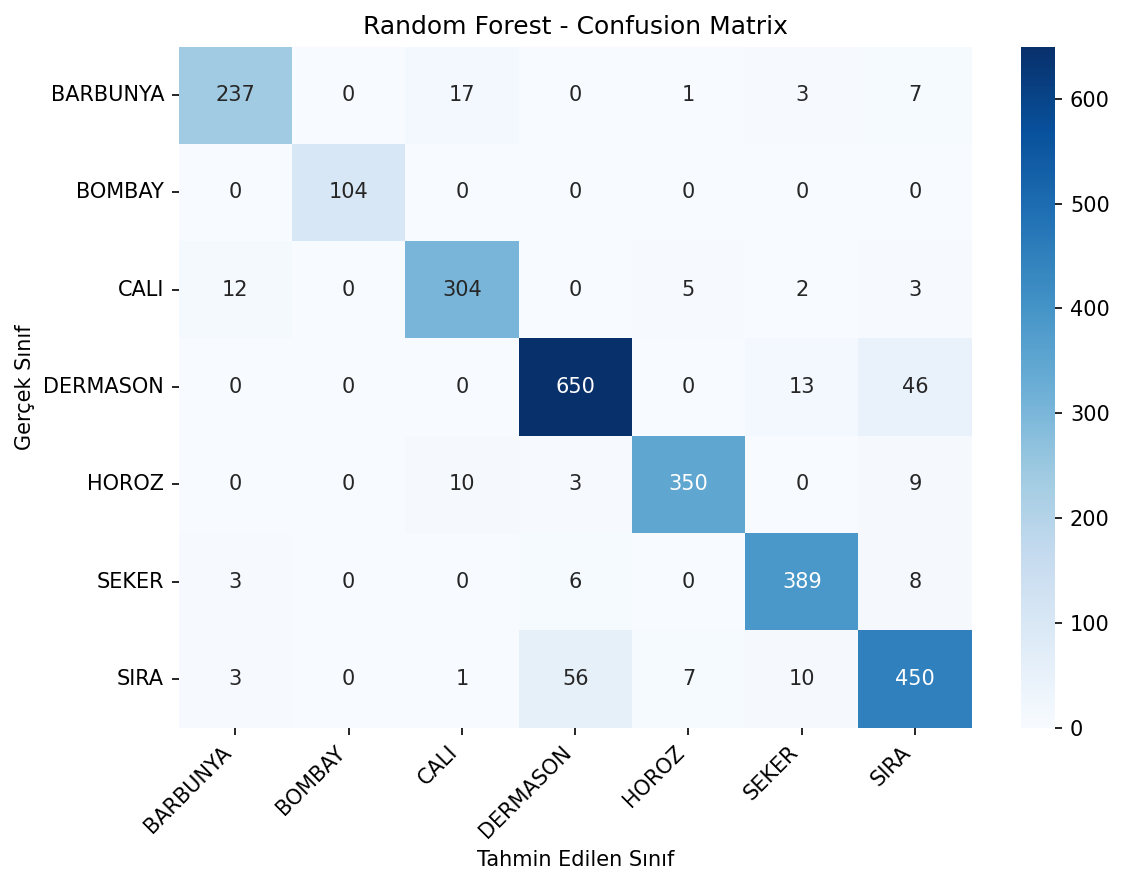

Random Forest confusion_matrix kaydedildi: C:\Users\AHMET ÇOLAK\Desktop\Veri_Bilimi_Proje\reports\figures\kisi2_random_forest_confusion_matrix.png


In [8]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=1 
)

rf_results, rf_cm, rf_pred = evaluate_model(
    "Random Forest",
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

results.append(rf_results)
confusion_matrices["Random Forest"] = rf_cm

save_confusion_matrix(
    rf_cm,
    "Random Forest",
    FIGURES_DIR / "kisi2_random_forest_confusion_matrix.png"
)

9- YSA/MLP MODELİ


YSA Sonuçları:
Accuracy: 0.9276485788113695
Weighted Precision: 0.9277330600851514
Weighted Recall: 0.9276485788113695
Weighted F1-score: 0.9276637172948545

Classification Report:
              precision    recall  f1-score   support

    BARBUNYA       0.92      0.92      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.94      0.93       326
    DERMASON       0.92      0.93      0.93       709
       HOROZ       0.97      0.94      0.96       372
       SEKER       0.95      0.96      0.95       406
        SIRA       0.88      0.87      0.88       527

    accuracy                           0.93      2709
   macro avg       0.94      0.94      0.94      2709
weighted avg       0.93      0.93      0.93      2709



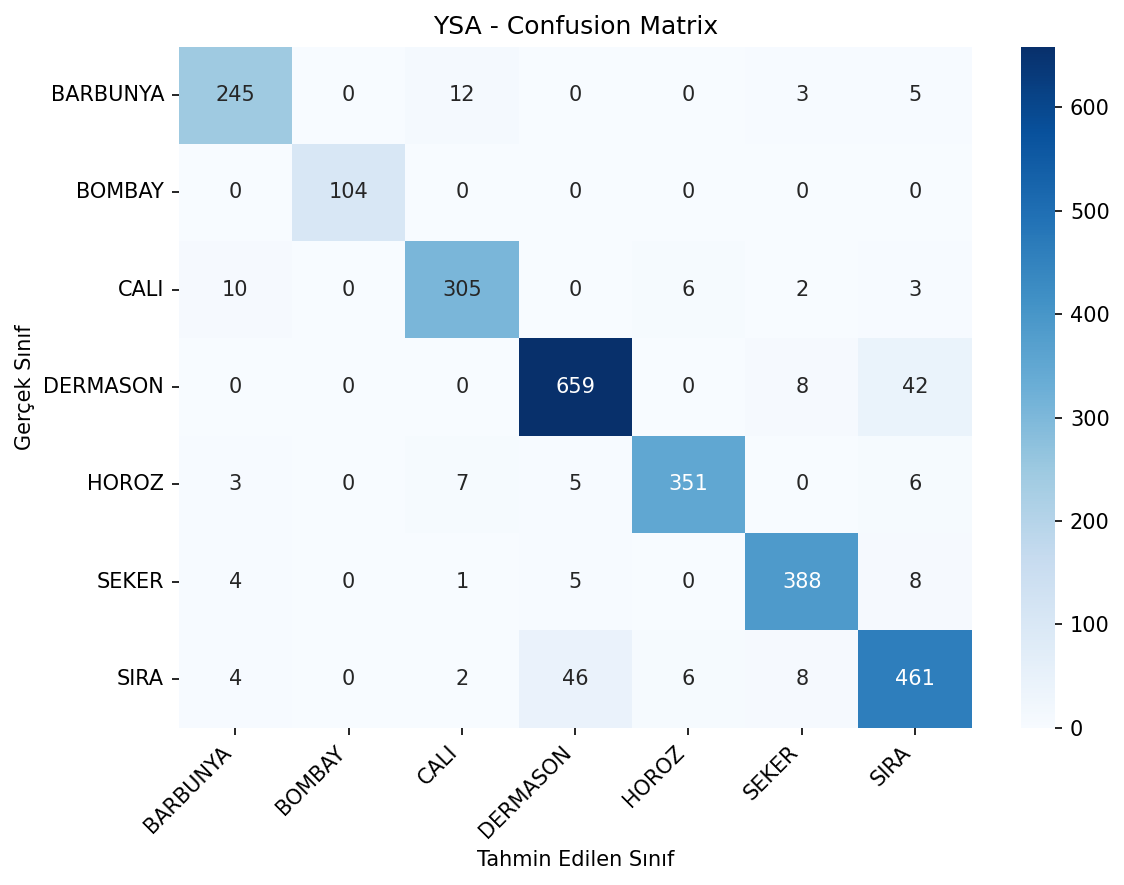

YSA confusion_matrix kaydedildi: C:\Users\AHMET ÇOLAK\Desktop\Veri_Bilimi_Proje\reports\figures\kisi2_ysa_confusion_matrix.png


In [9]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42,
)

mlp_results, mlp_cm, mlp_pred = evaluate_model(
    "YSA",
    mlp_model,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

results.append(mlp_results)
confusion_matrices["YSA"] = mlp_cm

save_confusion_matrix(
    mlp_cm,
    "YSA",
    FIGURES_DIR / "kisi2_ysa_confusion_matrix.png"
)

10- KİŞİ 2 SONUÇ TABLOSU OLUŞTURMA

In [10]:
kisi2_results_df = pd.DataFrame(results)

kisi2_results_df = kisi2_results_df.sort_values(
    by="Weighted F1-score",
    ascending=False
).reset_index(drop=True)

display(kisi2_results_df)

,Model,Accuracy,Weighted Precision,Weighted Recall,Weighted F1-score
0,YSA,0.927649,0.927733,0.927649,0.927664
1,SVM,0.921004,0.921411,0.921004,0.921078
2,Random Forest,0.916944,0.917019,0.916944,0.916887


11- SONUÇLARIN CSV OLARAK KAYDEDİLMESİ

In [11]:
kisi2_results_df.to_csv(KISI2_RESULTS_PATH, index=False, encoding="utf-8-sig")

print("Kişi 2 modellerinin sonuçları kaydedildi:")
print(KISI2_RESULTS_PATH)



Kişi 2 modellerinin sonuçları kaydedildi:
C:\Users\AHMET ÇOLAK\Desktop\Veri_Bilimi_Proje\reports\results\kisi2_model_sonuclari.csv


12- ÇIKTI DOSYALARININ KONTROLÜ

In [12]:
expected_files = [
    KISI2_RESULTS_PATH,
    FIGURES_DIR / "kisi2_svm_confusion_matrix.png",
    FIGURES_DIR / "kisi2_random_forest_confusion_matrix.png",
    FIGURES_DIR / "kisi2_ysa_confusion_matrix.png"
]

for file_path in expected_files:
    if file_path.exists():
        print(f"{file_path.name} dosyası başarıyla oluşturuldu.")
    else:
        print(f"{file_path.name} dosyası oluşturulamadı.")

kisi2_model_sonuclari.csv dosyası başarıyla oluşturuldu.
kisi2_svm_confusion_matrix.png dosyası başarıyla oluşturuldu.
kisi2_random_forest_confusion_matrix.png dosyası başarıyla oluşturuldu.
kisi2_ysa_confusion_matrix.png dosyası başarıyla oluşturuldu.
